# Figure 5b — NSCLC-relevant MoA enrichment versus random drug lists

Purpose: test whether top-ranked observed LINCS and DEPICT-predicted lists are enriched for **NSCLC-relevant MoA classes** compared with random lists from the same annotated shared drug universe.

Main endpoint:

`is_nsclc_relevant_moa = broad_moa_class in {PI3K-AKT-mTOR, RTK/TKI, p53/apoptosis, CDK/cell cycle, MAPK/MEK/ERK}`

This notebook uses `drug_meta['moa']` and `drug_meta['target']` to assign broad MoA classes. `clinical_phase` is not treated as NSCLC-specific evidence.

## Required files

Put these files in `./data/` relative to this notebook:

```text
reverseScore_predicted_All.csv
reverseScore_observed_All.csv
repurposing_drugs_20200324.txt
```

`repurposing_drugs_20200324.txt` is the Broad Drug Repurposing Hub metadata file. If your copy has the 9-line preamble, the code below will read it with `skiprows=9`.

In [1]:

# %%
from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# -------------------------
# User-editable paths
# -------------------------
PROJECT_DIR = Path.cwd()
DATA_DIR = PROJECT_DIR / "data"
FIG_DIR = PROJECT_DIR / "figures" / "figure2"
TABLE_DIR = PROJECT_DIR / "tables" / "figure2"
FIG_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

FINAL_DF_PRED_PATH = DATA_DIR / "reverseScore_predicted_All.csv"
FINAL_DF_ORIG_PATH = DATA_DIR / "reverseScore_observed_All.csv"
DRUG_META_PATH = DATA_DIR / "repurposing_drugs_20200324.txt"

N_PERMUTATIONS = 10_000
K_VALUES = [20, 50, 100, 200]
RANDOM_SEED = 20260708

# Figure 2B is now forced to use the same ranking/annotation logic as Figure 2D-left:
# top-K is taken from the shared observed-predicted LINCS universe, and drugs without
# usable Drug Repurposing Hub moa/target annotation are treated as Non-related/not found.
RANK_WITHIN_ANNOTATED_UNIVERSE = False


In [2]:

# %%
def set_publication_style():
    plt.rcParams.update({
        "figure.dpi": 150,
        "savefig.dpi": 600,
        "font.family": "DejaVu Sans",
        "font.size": 8,
        "axes.labelsize": 8,
        "axes.titlesize": 9,
        "xtick.labelsize": 7,
        "ytick.labelsize": 7,
        "legend.fontsize": 7,
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
        "svg.fonttype": "none",
    })
set_publication_style()

SOURCE_ORDER = ["Observed LINCS", "DEPICT-predicted LINCS"]
SOURCE_COLORS = {"Observed LINCS": "#3B6EA8", "DEPICT-predicted LINCS": "#D96C3B"}

MOA_CLASSES = [
    "PI3K-AKT-mTOR",
    "RTK/TKI",
    "p53/apoptosis",
    "CDK/cell cycle",
    "MAPK/MEK/ERK",
    "Non-related/not found",
]
NSCLC_RELEVANT_CLASSES = set(MOA_CLASSES[:-1])


def normalize_drug_name(x):
    if pd.isna(x):
        return np.nan
    x = str(x).strip().lower()
    x = x.replace("–", "-").replace("—", "-").replace("−", "-")
    x = re.sub(r"[^a-z0-9]+", "", x)
    aliases = {
        "nvpbez235": "dactolisib",
        "bez235": "dactolisib",
        "gsk2126458": "omipalisib",
        "gdc0941": "pictilisib",
        "mepacrine": "quinacrine",
        "epoxycholesterol": "epoxycholesterol",
    }
    return aliases.get(x, x)


def read_csv_drop_unnamed(path, **kwargs):
    df = pd.read_csv(path, **kwargs)
    unnamed = [c for c in df.columns if str(c).startswith("Unnamed:")]
    if unnamed:
        df = df.drop(columns=unnamed)
    return df


def load_screening_tables():
    pred = read_csv_drop_unnamed(FINAL_DF_PRED_PATH)
    orig = read_csv_drop_unnamed(FINAL_DF_ORIG_PATH)
    required = {"pert_iname", "reverse_score"}
    for name, df in {"final_df_pred": pred, "final_df_orig": orig}.items():
        missing = required - set(df.columns)
        if missing:
            raise ValueError(f"{name} is missing required columns: {missing}")
    return pred, orig


def best_per_drug(df, source_label):
    tmp = df.dropna(subset=["pert_iname", "reverse_score"]).copy()
    idx = tmp.groupby("pert_iname")["reverse_score"].idxmax()
    out = tmp.loc[idx].copy()
    out = out.sort_values("reverse_score", ascending=False).reset_index(drop=True)
    out["rank"] = np.arange(1, len(out) + 1)
    out["source"] = source_label
    out["drug_key"] = out["pert_iname"].map(normalize_drug_name)
    return out


def load_drug_meta():
    try:
        meta = pd.read_csv(DRUG_META_PATH, sep="\t", skiprows=9)
    except Exception:
        meta = pd.read_csv(DRUG_META_PATH, sep="\t")
    meta = meta.rename(columns={c: c.strip() for c in meta.columns})
    name_candidates = ["pert_iname", "name", "drug", "compound", "broad_id"]
    name_col = next((c for c in name_candidates if c in meta.columns), None)
    if name_col is None:
        raise ValueError(f"Could not find a drug-name column in drug_meta. Columns are: {list(meta.columns)}")
    meta["meta_drug_name"] = meta[name_col]
    meta["drug_key"] = meta["meta_drug_name"].map(normalize_drug_name)
    return meta.dropna(subset=["drug_key"]).drop_duplicates("drug_key", keep="first")


def assign_broad_moa_from_text(text):
    t = "" if pd.isna(text) else str(text).lower()
    t = t.replace("–", "-").replace("—", "-").replace("−", "-")

    # Order matters for a single display class. The endpoint itself uses any relevant class.
    if re.search(r"pi3k|phosphoinositide|akt\b|\bmtor\b|mtorc|pdk1", t):
        return "PI3K-AKT-mTOR"
    if re.search(r"\bmek\b|\berk\b|\bmapk\b|\braf\b|\bbraf\b|\bkras\b", t):
        return "MAPK/MEK/ERK"
    if re.search(r"egfr|erbb|her2|alk\b|ros1|\bmet\b|fgfr|vegfr|pdgfr|\bkit\b|flt3|igf-?1?r|ret\b|ntrk|tyrosine kinase|\btki\b", t):
        return "RTK/TKI"
    if re.search(r"\bcdk\b|cyclin|cell cycle|checkpoint|chk1|chk2|aurora|wee1|plk|polo", t):
        return "CDK/cell cycle"
    if re.search(r"p53|tp53|mdm2|apopto|bcl|death receptor|trail|dr4|dr5|retinoid", t):
        return "p53/apoptosis"
    return "Non-related/not found"


def annotate_meta_moa(meta):
    """Assign broad MoA classes from Drug Repurposing Hub MoA/target text only.

    This intentionally matches the Figure 2D-left MoA-composition logic.
    Do not use clinical_phase, indication, disease_area, or drug name for this
    endpoint, because those fields can make Figure 2B count a drug as
    NSCLC-relevant when Figure 2D-left assigns it to Non-related/not found.
    """
    text_cols = [c for c in ["moa", "target"] if c in meta.columns]
    if not text_cols:
        raise ValueError(
            "drug_meta must contain at least one of ['moa', 'target'] "
            "to define broad_moa_class."
        )
    meta = meta.copy()
    meta["annotation_text"] = meta[text_cols].fillna("").astype(str).agg(" | ".join, axis=1)
    meta["broad_moa_class"] = meta["annotation_text"].map(assign_broad_moa_from_text)
    meta["is_nsclc_relevant_moa"] = meta["broad_moa_class"].isin(NSCLC_RELEVANT_CLASSES)
    return meta


def empirical_p_value(null_values, observed_value):
    null_values = np.asarray(null_values)
    return (1 + np.sum(null_values >= observed_value)) / (1 + len(null_values))


def save_figure(fig, stem, show=True):
    """Display the figure inline in the notebook and save PDF/PNG/SVG copies."""
    fig.tight_layout()
    if show:
        display(fig)
    for ext in ["pdf", "png", "svg"]:
        fig.savefig(FIG_DIR / f"{stem}.{ext}", bbox_inches="tight")
    plt.close(fig)
    print(f"Displayed and saved {FIG_DIR / (stem + '.pdf')}")


In [3]:

# %%
final_df_pred, final_df_orig = load_screening_tables()
drug_meta = annotate_meta_moa(load_drug_meta())

pred_ranked_all = best_per_drug(final_df_pred, "DEPICT-predicted LINCS")
orig_ranked_all = best_per_drug(final_df_orig, "Observed LINCS")

shared_keys = sorted(set(pred_ranked_all["drug_key"]).intersection(set(orig_ranked_all["drug_key"])))
shared_key_set = set(shared_keys)

# Use the same shared-universe ranking logic as Figure 2D-left.
pred_ranked = pred_ranked_all[pred_ranked_all["drug_key"].isin(shared_key_set)].copy()
orig_ranked = orig_ranked_all[orig_ranked_all["drug_key"].isin(shared_key_set)].copy()

pred_ranked = pred_ranked.sort_values("reverse_score", ascending=False).reset_index(drop=True)
orig_ranked = orig_ranked.sort_values("reverse_score", ascending=False).reset_index(drop=True)
pred_ranked["rank"] = np.arange(1, len(pred_ranked) + 1)
orig_ranked["rank"] = np.arange(1, len(orig_ranked) + 1)

# Build a complete endpoint table for every shared drug.
# Missing drug_meta or missing moa/target is treated as Non-related/not found,
# which makes Figure 2B consistent with Figure 2D-left.
endpoint_df = pd.DataFrame({"drug_key": shared_keys})
endpoint_df = endpoint_df.merge(
    drug_meta[["drug_key", "meta_drug_name", "broad_moa_class", "is_nsclc_relevant_moa"] + [c for c in ["moa", "target"] if c in drug_meta.columns]],
    on="drug_key",
    how="left",
)
endpoint_df["broad_moa_class"] = endpoint_df["broad_moa_class"].fillna("Non-related/not found")
endpoint_df["is_nsclc_relevant_moa"] = endpoint_df["broad_moa_class"].isin(NSCLC_RELEVANT_CLASSES)

print("Shared observed-predicted drugs:", len(shared_keys))
print("Figure 2B endpoint now matches Figure 2D-left:")
print("  - rank top-K within the shared observed-predicted LINCS universe")
print("  - assign broad_moa_class from drug_meta moa/target only")
print("  - treat missing drug_meta/moa/target as Non-related/not found")
print("\nMoA class counts in shared universe:")
print(endpoint_df["broad_moa_class"].value_counts(dropna=False))

eligible_key_array = np.asarray(shared_keys)
eligible_endpoint = endpoint_df.set_index("drug_key")["is_nsclc_relevant_moa"].astype(bool)

# Save matched universe for audit.
endpoint_df.to_csv(TABLE_DIR / "fig2b_shared_universe_moa_endpoint_consistent_with_2d_left.csv", index=False)


Shared observed-predicted drugs: 11782
Figure 2B endpoint now matches Figure 2D-left:
  - rank top-K within the shared observed-predicted LINCS universe
  - assign broad_moa_class from drug_meta moa/target only
  - treat missing drug_meta/moa/target as Non-related/not found

MoA class counts in shared universe:
broad_moa_class
Non-related/not found    11535
RTK/TKI                     97
PI3K-AKT-mTOR               43
MAPK/MEK/ERK                37
p53/apoptosis               35
CDK/cell cycle              35
Name: count, dtype: int64


In [4]:

# %%
rng = np.random.default_rng(RANDOM_SEED)

records = []
null_records = []

for source_label, ranked in [("Observed LINCS", orig_ranked), ("DEPICT-predicted LINCS", pred_ranked)]:
    for k in K_VALUES:
        top_keys = ranked.head(k)["drug_key"].tolist()
        effective_k = len(top_keys)
        if effective_k == 0:
            raise ValueError(f"No evaluable top drugs for {source_label}, K={k}.")

        observed_values = eligible_endpoint.reindex(top_keys).fillna(False).astype(bool)
        observed_prop = float(observed_values.mean())
        observed_count = int(observed_values.sum())

        null_props = np.empty(N_PERMUTATIONS, dtype=float)
        for b in range(N_PERMUTATIONS):
            sampled = rng.choice(eligible_key_array, size=effective_k, replace=False)
            null_props[b] = float(eligible_endpoint.loc[sampled].mean())

        null_mean = float(null_props.mean())
        null_low = float(np.quantile(null_props, 0.025))
        null_high = float(np.quantile(null_props, 0.975))
        p_emp = empirical_p_value(null_props, observed_prop)
        enrichment_ratio = observed_prop / null_mean if null_mean > 0 else np.nan

        records.append({
            "source": source_label,
            "requested_K": k,
            "effective_K": effective_k,
            "endpoint": "NSCLC-relevant MoA class from drug_meta moa/target",
            "observed_proportion": observed_prop,
            "observed_count": observed_count,
            "null_mean": null_mean,
            "null_2p5": null_low,
            "null_97p5": null_high,
            "empirical_p_ge_observed": p_emp,
            "enrichment_ratio_vs_null_mean": enrichment_ratio,
        })

        null_records.extend({
            "source": source_label,
            "requested_K": k,
            "effective_K": effective_k,
            "permutation": b,
            "null_proportion": float(v),
        } for b, v in enumerate(null_props))

summary = pd.DataFrame(records)
null_df = pd.DataFrame(null_records)
summary.to_csv(TABLE_DIR / "fig2b_nsclc_relevant_moa_enrichment_summary.csv", index=False)
null_df.to_csv(TABLE_DIR / "fig2b_nsclc_relevant_moa_enrichment_null_distributions.csv", index=False)
summary


,source,requested_K,effective_K,endpoint,observed_proportion,observed_count,null_mean,null_2p5,null_97p5,empirical_p_ge_observed,enrichment_ratio_vs_null_mean
0,Observed LINCS,20,20,NSCLC-relevant MoA class from drug_meta moa/ta...,0.85,17,0.020870,0.000,0.100,0.0001,40.728318
1,Observed LINCS,50,50,NSCLC-relevant MoA class from drug_meta moa/ta...,0.52,26,0.021318,0.000,0.060,0.0001,24.392532
2,Observed LINCS,100,100,NSCLC-relevant MoA class from drug_meta moa/ta...,0.43,43,0.021051,0.000,0.050,0.0001,20.426583
3,Observed LINCS,200,200,NSCLC-relevant MoA class from drug_meta moa/ta...,0.33,66,0.020931,0.005,0.045,0.0001,15.766089
4,DEPICT-predicted LINCS,20,20,NSCLC-relevant MoA class from drug_meta moa/ta...,0.75,15,0.020705,0.000,0.100,0.0001,36.223135
5,DEPICT-predicted LINCS,50,50,NSCLC-relevant MoA class from drug_meta moa/ta...,0.54,27,0.020902,0.000,0.060,0.0001,25.834848
6,DEPICT-predicted LINCS,100,100,NSCLC-relevant MoA class from drug_meta moa/ta...,0.37,37,0.021004,0.000,0.050,0.0001,17.615692
7,DEPICT-predicted LINCS,200,200,NSCLC-relevant MoA class from drug_meta moa/ta...,0.27,54,0.020971,0.005,0.045,0.0001,12.875229


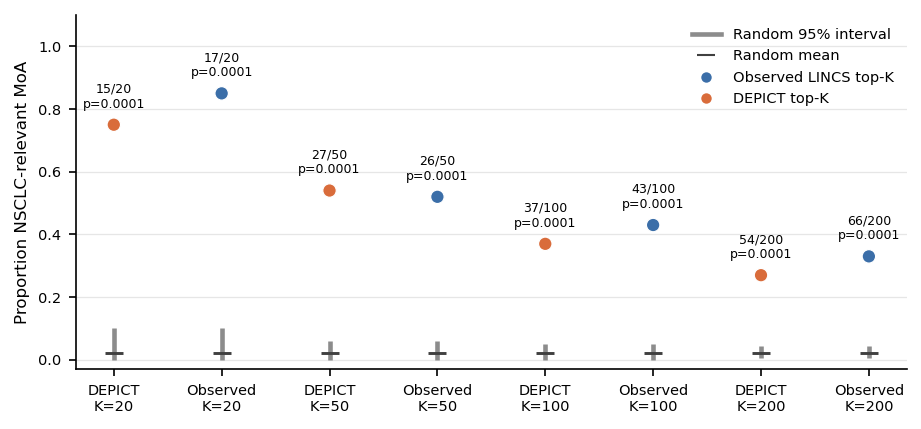

Displayed and saved /work/users/m/e/meisheng/Dissertation/Experiments_Feb152025/code/transformer/Jul7WholeData/Jun2026New/analysis/DrugScreening/figures/figure2/fig2b_nsclc_relevant_moa_enrichment.pdf


In [5]:
# %%
from IPython.display import display
from matplotlib.lines import Line2D

plot_df = summary.copy()
plot_df["x_label"] = (
    plot_df["source"].map({
        "Observed LINCS": "Observed",
        "DEPICT-predicted LINCS": "DEPICT",
    })
    + "\nK="
    + plot_df["requested_K"].astype(str)
)
plot_df = plot_df.sort_values(["requested_K", "source"]).reset_index(drop=True)

x = np.arange(len(plot_df))
colors = [SOURCE_COLORS[s] for s in plot_df["source"]]

fig, ax = plt.subplots(figsize=(6.2, 2.9))

# Null interval and mean.
ax.vlines(
    x,
    plot_df["null_2p5"],
    plot_df["null_97p5"],
    color="0.55",
    lw=2.2,
    label="Random 95% interval",
)
ax.scatter(
    x,
    plot_df["null_mean"],
    color="0.25",
    marker="_",
    s=80,
    linewidths=1.4,
    label="Random mean",
    zorder=3,
)

# Observed top-K proportion.
ax.scatter(
    x,
    plot_df["observed_proportion"],
    color=colors,
    s=42,
    edgecolor="white",
    linewidth=0.6,
    label="Top-K observed proportion",
    zorder=4,
)

for xi, row in plot_df.iterrows():
    ax.text(
        xi,
        min(1.03, row["observed_proportion"] + 0.045),
        f"{int(row['observed_count'])}/{int(row['effective_K'])}\n"
        f"p={row['empirical_p_ge_observed']:.3g}",
        ha="center",
        va="bottom",
        fontsize=6,
    )

ax.set_xticks(x)
ax.set_xticklabels(plot_df["x_label"], rotation=0)
ax.set_ylim(-0.03, 1.10)
ax.set_ylabel("Proportion NSCLC-relevant MoA")
ax.grid(axis="y", color="0.90", lw=0.6)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

legend_handles = [
    Line2D([0], [0], color="0.55", lw=2.2, label="Random 95% interval"),
    Line2D([0], [0], marker="_", color="0.25", linestyle="None", markersize=9, label="Random mean"),
    Line2D(
        [0],
        [0],
        marker="o",
        color="w",
        markerfacecolor=SOURCE_COLORS["Observed LINCS"],
        markeredgecolor="white",
        markersize=6,
        label="Observed LINCS top-K",
    ),
    Line2D(
        [0],
        [0],
        marker="o",
        color="w",
        markerfacecolor=SOURCE_COLORS["DEPICT-predicted LINCS"],
        markeredgecolor="white",
        markersize=6,
        label="DEPICT top-K",
    ),
]
ax.legend(handles=legend_handles, frameon=False, loc="upper right", bbox_to_anchor=(1.0, 1.0))

fig.tight_layout()

# Explicitly show in notebook cell before save_figure closes the figure.
display(fig)

# Still save PDF/PNG/SVG.
save_figure(fig, "fig2b_nsclc_relevant_moa_enrichment", show=False)

In [6]:

# %%
# Audit table: top drugs and their assigned broad MoA class.
# This audit is the quickest way to verify Figure 2B is consistent with Figure 2D-left.
def topk_audit(ranked, source, k=50):
    out = ranked.head(k).merge(
        endpoint_df[["drug_key", "meta_drug_name", "broad_moa_class", "is_nsclc_relevant_moa"] + [c for c in ["moa", "target"] if c in endpoint_df.columns]],
        on="drug_key",
        how="left",
    )
    out["broad_moa_class"] = out["broad_moa_class"].fillna("Non-related/not found")
    out["is_nsclc_relevant_moa"] = out["broad_moa_class"].isin(NSCLC_RELEVANT_CLASSES)
    out["source"] = source
    return out

audit_top50 = pd.concat([
    topk_audit(orig_ranked, "Observed LINCS", 50),
    topk_audit(pred_ranked, "DEPICT-predicted LINCS", 50),
], ignore_index=True)
audit_top50.to_csv(TABLE_DIR / "fig2b_top50_moa_assignment_audit.csv", index=False)

# Top-20 count check. These numbers should now match Figure 2D-left after using
# the same shared-universe ranking and the same moa/target-only broad_moa_class logic.
top20_count_check = (
    audit_top50[audit_top50["rank"] <= 20]
    .groupby(["source", "broad_moa_class"])
    .size()
    .unstack(fill_value=0)
)
display(top20_count_check)

audit_top50[["source", "rank", "pert_iname", "reverse_score", "broad_moa_class", "is_nsclc_relevant_moa"]].head(40)


broad_moa_class,CDK/cell cycle,MAPK/MEK/ERK,Non-related/not found,PI3K-AKT-mTOR,RTK/TKI,p53/apoptosis
source,,,,,,
DEPICT-predicted LINCS,1,1,5,8,4,1
Observed LINCS,0,0,3,11,4,2


,source,rank,pert_iname,reverse_score,broad_moa_class,is_nsclc_relevant_moa
0,Observed LINCS,1,wortmannin,0.839986,PI3K-AKT-mTOR,True
1,Observed LINCS,2,NVP-BEZ235,0.820359,PI3K-AKT-mTOR,True
2,Observed LINCS,3,NVP-TAE684,0.767374,RTK/TKI,True
3,Observed LINCS,4,GDC-0941,0.756509,PI3K-AKT-mTOR,True
4,Observed LINCS,5,WYE-125132,0.747868,PI3K-AKT-mTOR,True
5,Observed LINCS,6,torin-2,0.745217,PI3K-AKT-mTOR,True
6,Observed LINCS,7,GSK-2126458,0.743191,PI3K-AKT-mTOR,True
7,Observed LINCS,8,PI-103,0.741628,PI3K-AKT-mTOR,True
8,Observed LINCS,9,AZD-7762,0.736464,Non-related/not found,False
9,Observed LINCS,10,epoxycholesterol,0.735814,Non-related/not found,False
